In [3]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from collections import Counter

In [6]:
data_root = "/Users/leduongkhoa/hardhat_detection/data"

# Đọc train JSON
train_json_path = os.path.join(data_root, 'train', '_annotations.coco.json')
with open(train_json_path) as f:
    train_data = json.load(f)

print("Keys in JSON:", train_data.keys())
print("Number of images:", len(train_data['images']))
print("Number of annotations:", len(train_data['annotations']))
print("Categories:", train_data['categories'])

Keys in JSON: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 5269
Number of annotations: 20231
Categories: [{'id': 0, 'name': 'Workers', 'supercategory': 'none'}, {'id': 1, 'name': 'head', 'supercategory': 'Workers'}, {'id': 2, 'name': 'helmet', 'supercategory': 'Workers'}, {'id': 3, 'name': 'person', 'supercategory': 'Workers'}]


In [7]:
num_train_images = len(train_data['images'])
num_train_annotations = len(train_data['annotations'])
print(f'Train: {num_train_images} images, {num_train_annotations} objects')

# Đọc test JSON
test_json_path = os.path.join(data_root, 'test', '_annotations.coco.json')
with open(test_json_path) as f:
    test_data = json.load(f)
num_test_images = len(test_data['images'])
num_test_annotations = len(test_data['annotations'])
print(f'Test: {num_test_images} images, {num_test_annotations} objects')

Train: 5269 images, 20231 objects
Test: 1766 images, 6808 objects


In [8]:
print(f'Train avg objects/image: {num_train_annotations/num_train_images:.2f}')
print(f'Valid avg objects/image: {num_test_annotations/num_test_images:.2f}')

Train avg objects/image: 3.84
Valid avg objects/image: 3.86


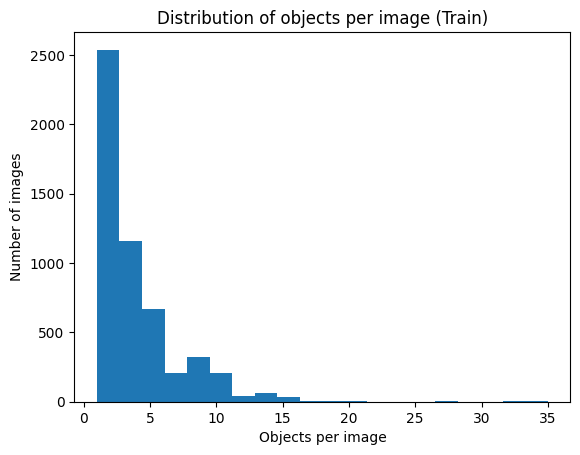

In [9]:
from collections import defaultdict
img_annot_count = defaultdict(int)
for ann in train_data['annotations']:
    img_annot_count[ann['image_id']] += 1

counts = list(img_annot_count.values())
plt.hist(counts, bins=20)
plt.xlabel('Objects per image')
plt.ylabel('Number of images')
plt.title('Distribution of objects per image (Train)')
plt.show()

In [11]:
# Tạo dict để tra cứu nhanh:
cat_id_to_name = {cat['id']: cat['name'] for cat in train_data['categories']}
img_id_to_info = {img['id']: img for img in train_data['images']}

Train class distribution:
  helmet: 14884
  head: 4874
  person: 473


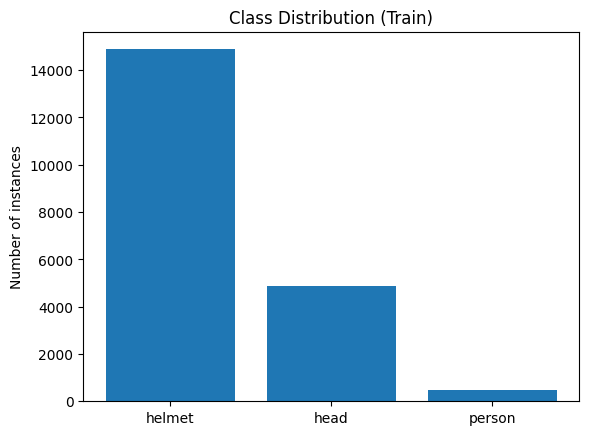

In [ ]:
class_counter = Counter()
for ann in train_data['annotations']:
    class_counter[cat_id_to_name[ann['category_id']]] += 1

print("Train class distribution:")
for cls, cnt in class_counter.items():
    print(f"  {cls}: {cnt}")

plt.bar(class_counter.keys(), class_counter.values()) # type: ignore
plt.title('Class Distribution (Train)')
plt.ylabel('Number of instances')
plt.show()

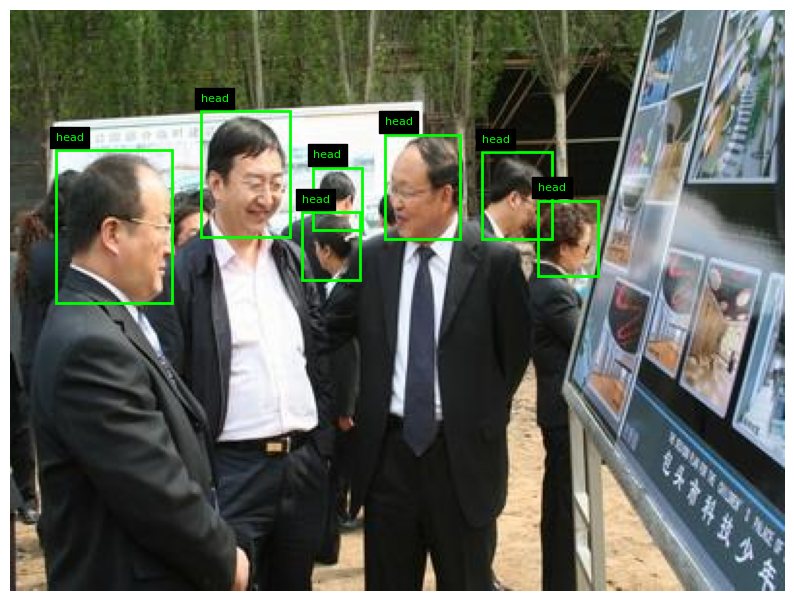

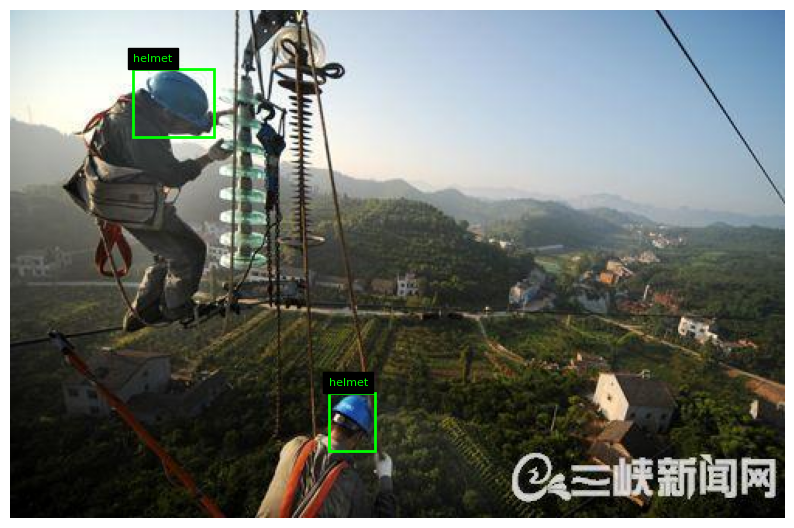

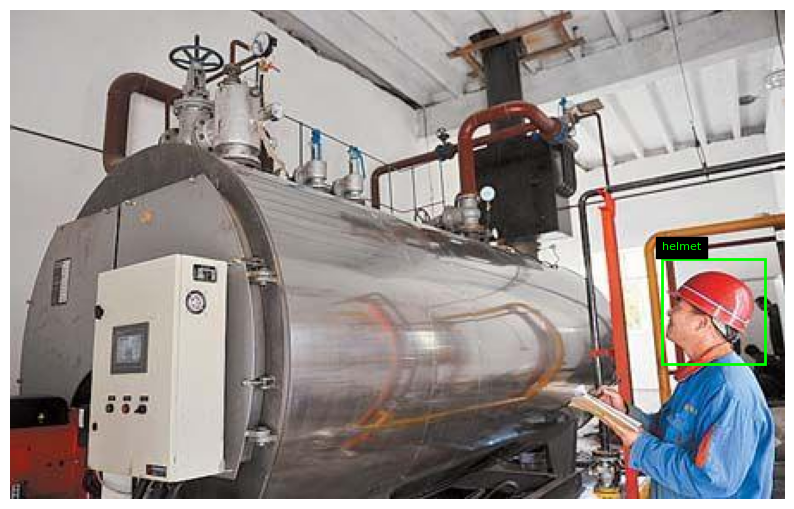

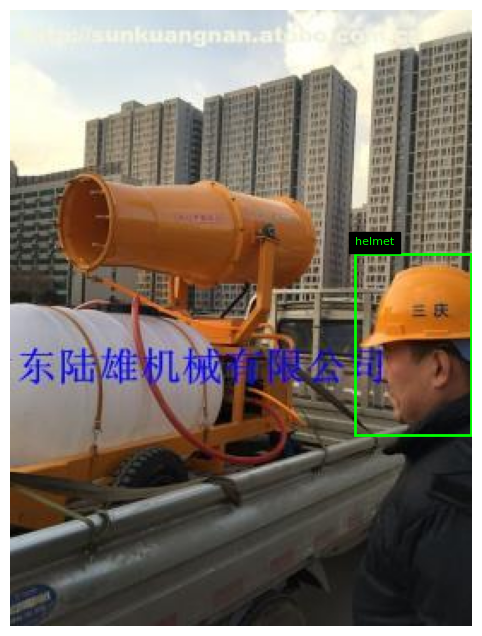

In [14]:
import random

def draw_coco_boxes(img_id, data, cat_id_to_name, img_dir):
    img_info = img_id_to_info[img_id]
    img_path = os.path.join(img_dir, img_info['file_name'])
    img = Image.open(img_path).convert('RGB')
    
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    
    # Lọc annotations thuộc ảnh này
    img_anns = [ann for ann in data['annotations'] if ann['image_id'] == img_id]
    for ann in img_anns:
        x, y, w, h = ann['bbox']
        cls_name = cat_id_to_name[ann['category_id']]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-5, cls_name, color='lime', fontsize=8, backgroundcolor='black')
    
    plt.axis('off')
    plt.show()

# Kiểm tra ngẫu nhiên 4 ảnh từ train
train_img_dir = os.path.join(data_root, 'train')
random_ids = random.sample(list(img_id_to_info.keys()), 4)
for img_id in random_ids:
    draw_coco_boxes(img_id, train_data, cat_id_to_name, train_img_dir)

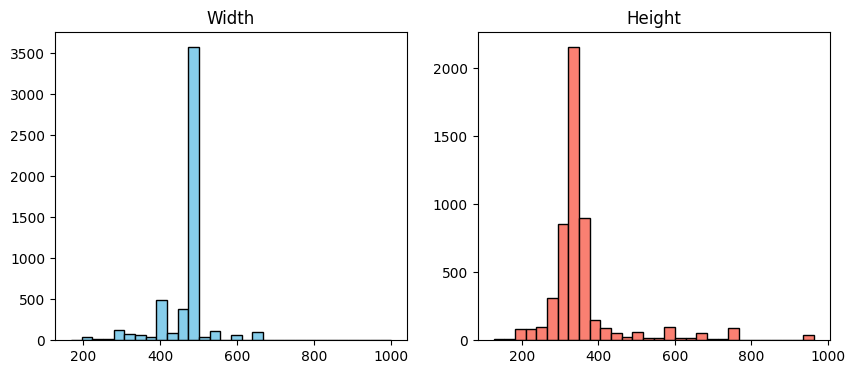

Width range: 168–1000, Height range: 126–963


In [15]:
widths = [img['width'] for img in train_data['images']]
heights = [img['height'] for img in train_data['images']]
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].hist(widths, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Width')
axes[1].hist(heights, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Height')
plt.show()
print(f"Width range: {min(widths)}–{max(widths)}, Height range: {min(heights)}–{max(heights)}")

In [20]:
# ==========================
# Check images without annotations
# ==========================

all_image_ids = {img["id"] for img in train_data["images"]}
annotated_image_ids = {ann["image_id"] for ann in train_data["annotations"]}

empty_image_ids = all_image_ids - annotated_image_ids

print("=" * 50)
print("Images without annotations")
print("=" * 50)
print(f"Total images: {len(all_image_ids)}")
print(f"Annotated images: {len(annotated_image_ids)}")
print(f"Images without annotations: {len(empty_image_ids)}")

if empty_image_ids:
    print("\nExample image ids:")
    print(list(empty_image_ids)[:10])
else:
    print("✅ No empty images found.")

Images without annotations
Total images: 5269
Annotated images: 5269
Images without annotations: 0
✅ No empty images found.


In [21]:
# ==========================
# Check invalid bounding boxes
# ==========================

invalid_bboxes = []

for ann in train_data["annotations"]:

    x, y, w, h = ann["bbox"]

    if w <= 0 or h <= 0:
        invalid_bboxes.append(ann)

print("=" * 50)
print("Bounding Box Validation")
print("=" * 50)
print(f"Invalid bounding boxes: {len(invalid_bboxes)}")

if invalid_bboxes:
    print("Example:")
    print(invalid_bboxes[:5])
else:
    print("✅ All bounding boxes are valid.")

Bounding Box Validation
Invalid bounding boxes: 0
✅ All bounding boxes are valid.


In [22]:
# ==========================
# Check bounding boxes outside image
# ==========================

invalid_location = []

for ann in train_data["annotations"]:

    image = img_id_to_info[ann["image_id"]]

    img_w = image["width"]
    img_h = image["height"]

    x, y, w, h = ann["bbox"]

    if (
        x < 0
        or y < 0
        or x + w > img_w
        or y + h > img_h
    ):
        invalid_location.append(ann)

print("=" * 50)
print("Bounding Box Location Check")
print("=" * 50)
print(f"Invalid location boxes: {len(invalid_location)}")

if invalid_location:
    print(invalid_location[:5])
else:
    print("✅ All bounding boxes lie inside images.")

Bounding Box Location Check
Invalid location boxes: 0
✅ All bounding boxes lie inside images.


In [23]:
bbox_widths = []
bbox_heights = []

for ann in train_data["annotations"]:

    _, _, w, h = ann["bbox"]

    bbox_widths.append(w)
    bbox_heights.append(h)

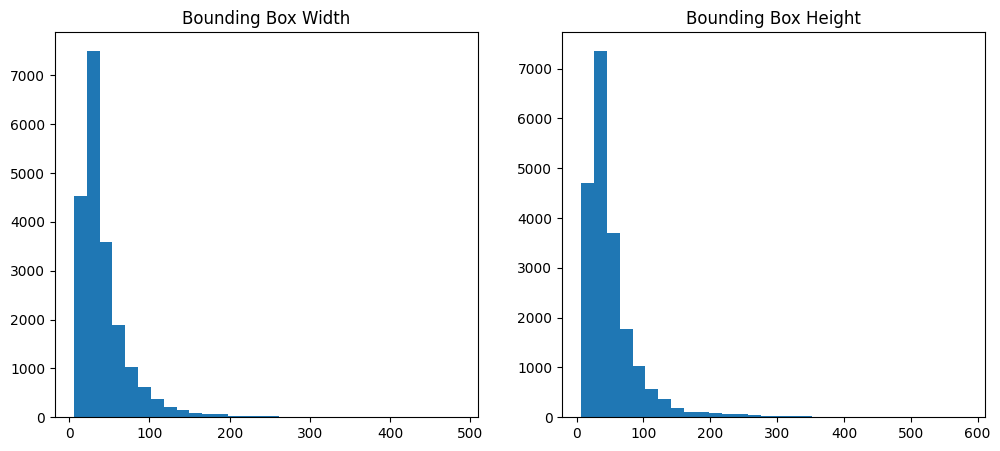

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(bbox_widths, bins=30)
axes[0].set_title("Bounding Box Width")

axes[1].hist(bbox_heights, bins=30)
axes[1].set_title("Bounding Box Height")

plt.show()

In [25]:
print("=" * 50)
print("Bounding Box Statistics")
print("=" * 50)

print(f"Width : min={min(bbox_widths):.1f}, max={max(bbox_widths):.1f}, mean={np.mean(bbox_widths):.1f}")

print(f"Height: min={min(bbox_heights):.1f}, max={max(bbox_heights):.1f}, mean={np.mean(bbox_heights):.1f}")

Bounding Box Statistics
Width : min=6.0, max=485.0, mean=42.5
Height: min=7.0, max=582.0, mean=51.6


In [26]:
aspect_ratios = []

for img in train_data["images"]:

    aspect_ratios.append(img["width"] / img["height"])

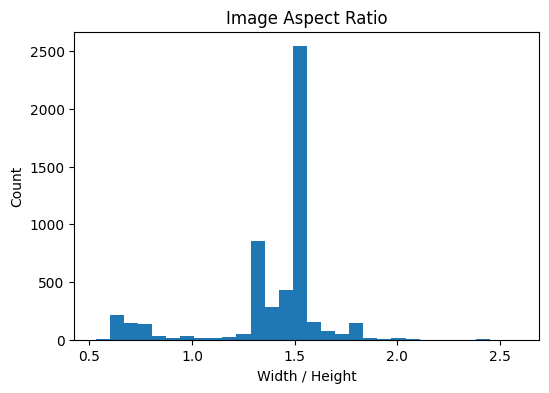

In [27]:
plt.figure(figsize=(6,4))
plt.hist(aspect_ratios, bins=30)

plt.title("Image Aspect Ratio")
plt.xlabel("Width / Height")
plt.ylabel("Count")
plt.show()